In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv('wine_data.csv', header = None, usecols=[0,1,2])
df.columns = ['Class,label', 'Alcohol', 'Malic acid']

In [45]:
df

,"Class,label",Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


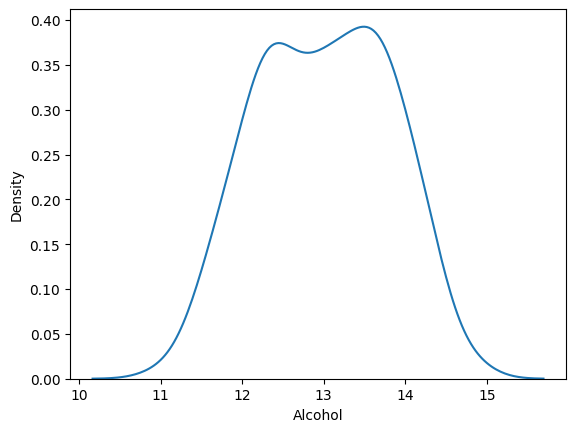

In [19]:
sns.kdeplot(df['Alcohol'])
plt.show()

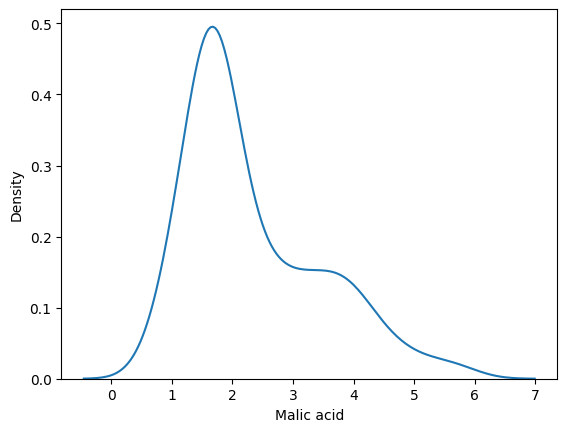

In [20]:
sns.kdeplot(df['Malic acid'])
plt.show()

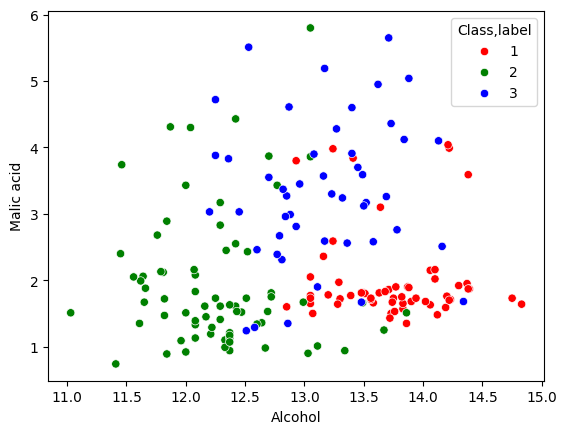

In [24]:
color_dict = {1:'red', 2:'green', 3:'blue'}
sns.scatterplot(x='Alcohol', y='Malic acid', hue='Class,label', data=df, palette=color_dict)
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class,label', axis=1),df['Class,label'], test_size=0.3, random_state=0)

In [27]:
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [29]:
scaler.fit(X_train)

MinMaxScaler()

In [30]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [32]:
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [33]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


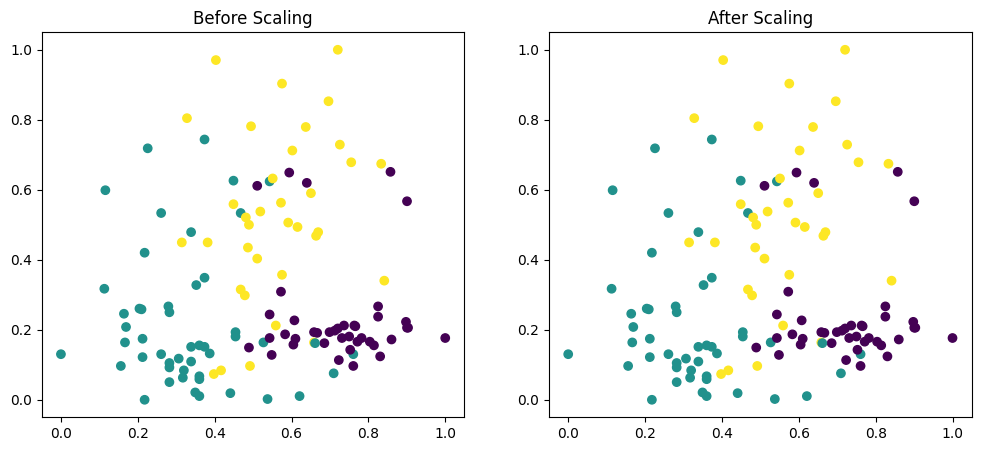

In [37]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
ax1.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train)
ax2.set_title('After Scaling')
plt.show()

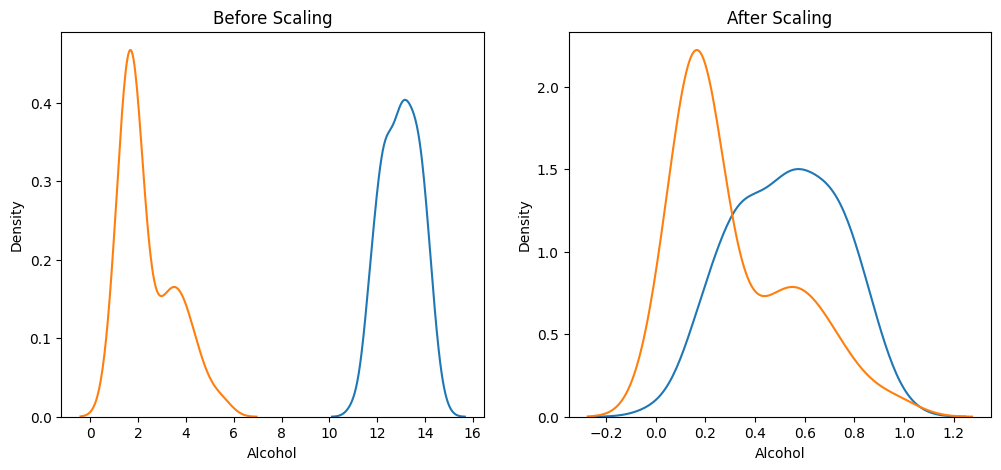

In [40]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

#Before Scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

#After Scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

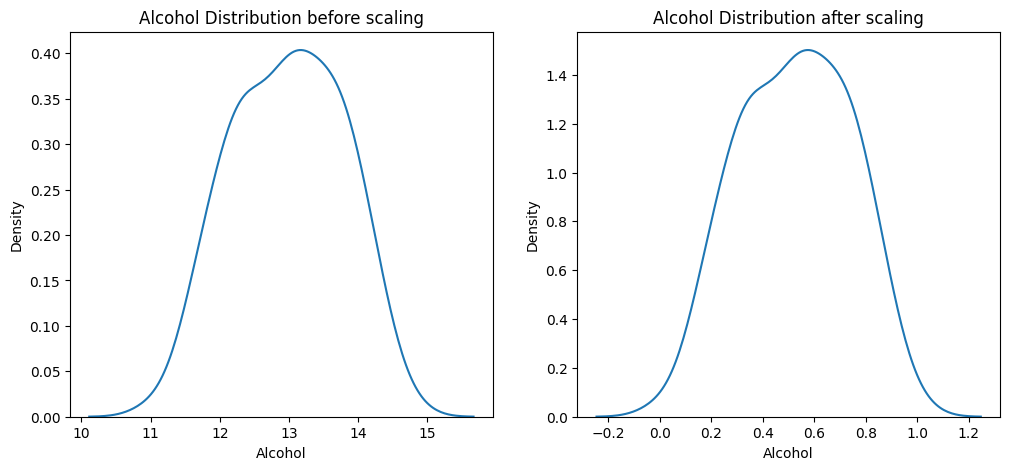

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
#before scaling
ax1.set_title('Alcohol Distribution before scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

#afetr scaling
ax2.set_title('Alcohol Distribution after scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

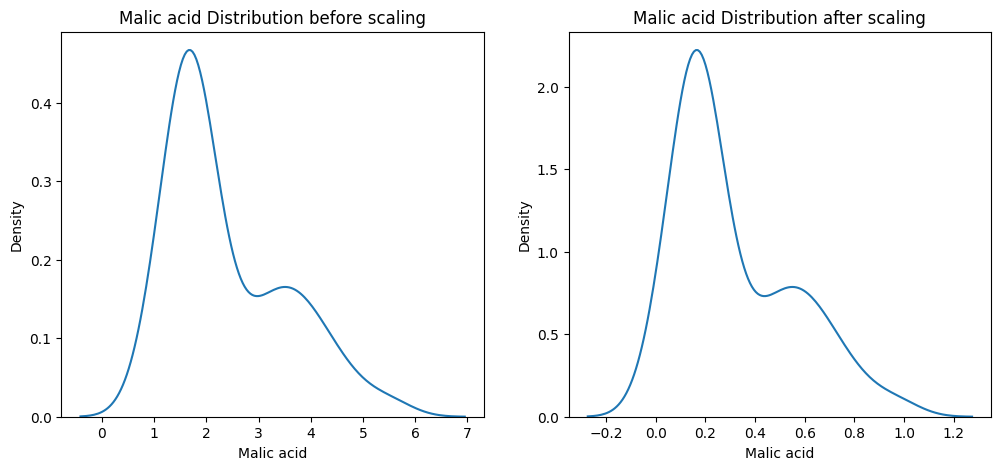

In [42]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

#before scaling
ax1.set_title('Malic acid Distribution before scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

#after scaling
ax2.set_title('Malic acid Distribution after scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()